# 4. Candidate space discussion

The previous notebook resolved one evaluated single-slot row. This notebook starts after that step and shows how many such rows are assembled into one distance-conditioned candidate space, pruned under the stored rule, and reduced to the frontier that is kept for later lookup.


## 0. Opening and notebook boundary

This notebook has one narrow scope.

- It begins from the evaluated single-slot row contract.
- It shows the full feasible single-slot space for one worked distance bin.
- It states the strict pruning rule used by the code.
- It ends at the stored frontier.

Later notebooks handle distance-bin lookup, rate-feasible expansion across a frame, and scheduler preparation.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

for path in (repo_root / "notebooks", repo_root / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from helpers.candidate_space_discussion_helpers import CandidateSpaceHelpers

# Notebook-wide visual identity: change this once to rerun under the other institutional theme.
helper = CandidateSpaceHelpers(theme="aalto_elec")
artifacts = helper.build_artifacts()

def show_figure(fig):
    display(fig)
    plt.close(fig)


## 1. Fixed input contract from notebook 3

The inherited object here is one evaluated single-slot row. The notebook now evaluates many rows of this same type at one fixed distance bin.


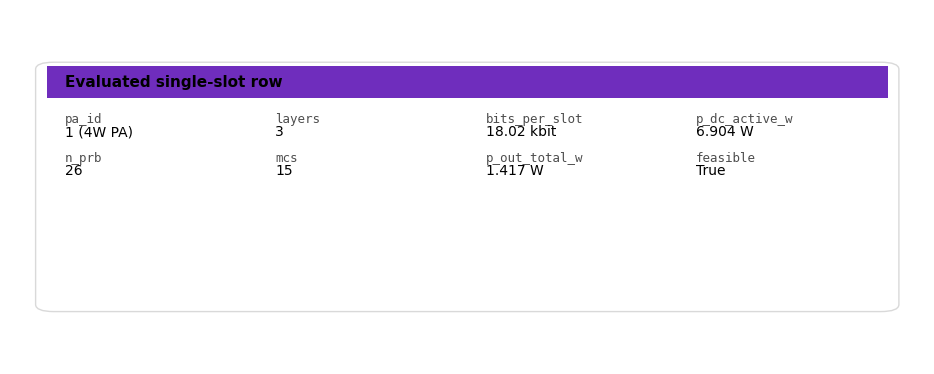

In [2]:
fig, _ = helper.plot_inherited_row_contract(artifacts)
show_figure(fig)


**Evaluated single-slot row contract inherited from the candidate-evaluation notebook.**

This card is one feasible active-slot primitive. The candidate-space notebook now evaluates many rows of this form at one fixed distance bin and compares them only on the stored single-slot axes.


## 2. Build the full feasible single-slot space for one worked distance bin

The worked bin in this notebook is `300 m`. Each point below is one feasible evaluated single-slot row at that fixed distance.


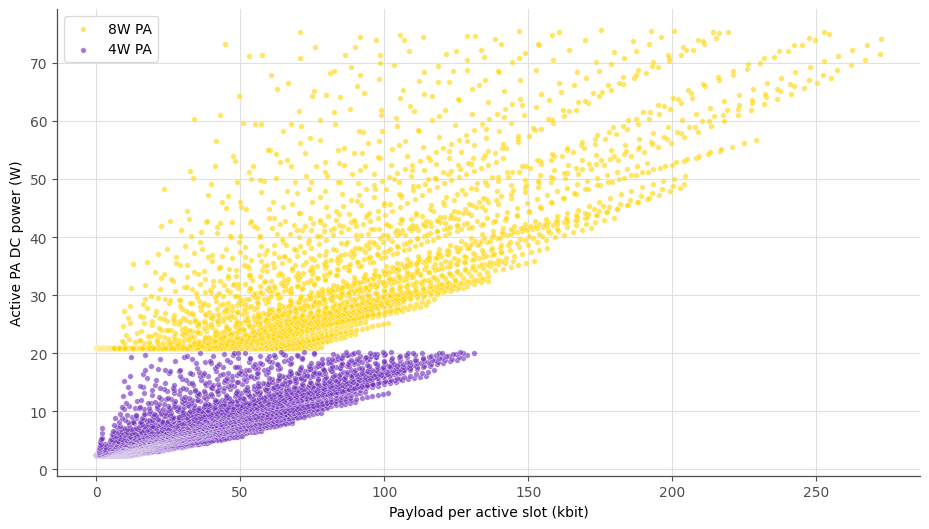

In [3]:
fig, _ = helper.plot_single_slot_space(artifacts)
show_figure(fig)


**Full feasible one-slot space for the worked 300 m distance bin.**

Each point is one feasible evaluated single-slot row. The horizontal axis is payload per active slot, not end-user rate over time, and the notebook is still entirely inside the single-slot storage stage.


## 3. Zoom into one local region of the full space

The full cloud is next reduced to one local region so the dominance relation can be seen clearly.


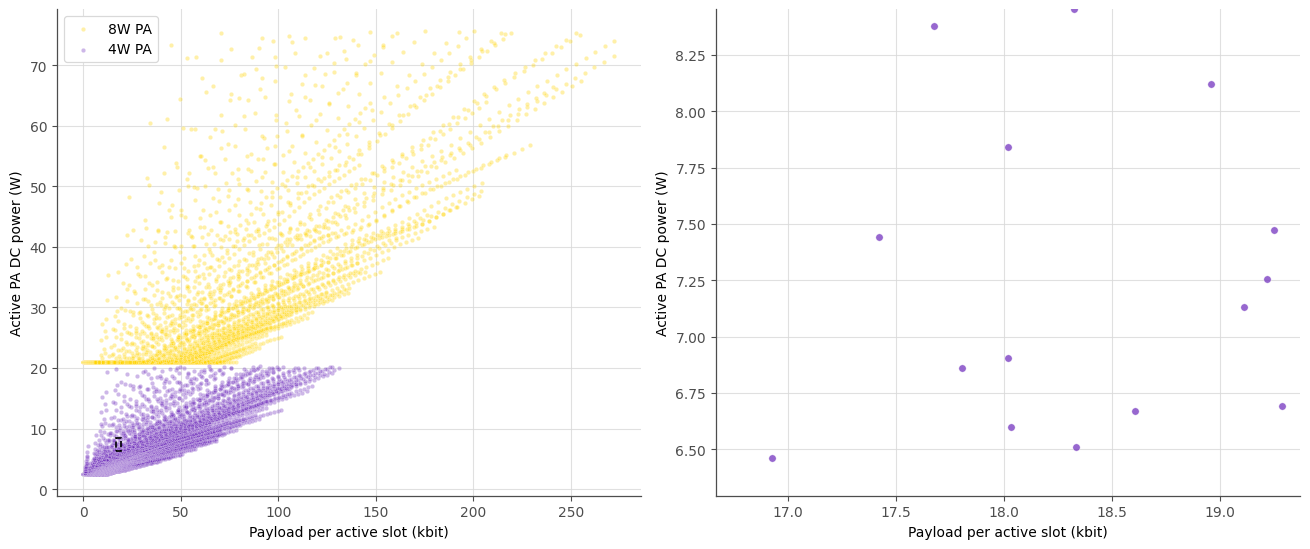

In [4]:
fig, _ = helper.plot_single_slot_space_zoom(artifacts)
show_figure(fig)


**Local region of the feasible one-slot space used to show strict dominance.**

The left panel marks one neighborhood inside the worked `300 m` space. The right panel isolates that neighborhood so rows with similar slot-level payload can be compared directly under the stored rule.


## 4. State the strict pruning rule

The stored frontier uses the exact same-PA pruning rule implemented in the code. A row is removable only when another row on the same PA family uses no more PRBs, draws no more active DC power, delivers no less payload per slot, and improves at least one of those axes strictly.


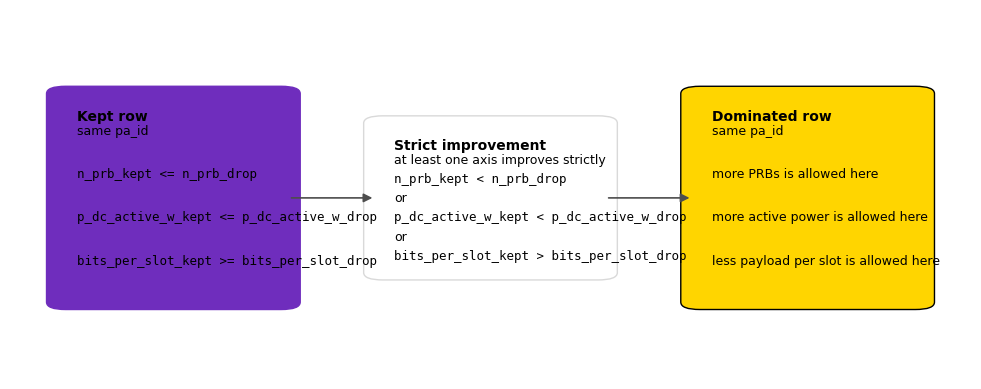

In [5]:
fig, _ = helper.plot_pruning_rule_diagram(artifacts)
show_figure(fig)


**Strict pruning rule used to reduce the feasible one-slot space to the stored frontier.**

The rule is applied within each PA family. The stored frontier therefore keeps only rows that remain non-dominated on the single-slot comparison axes used by the implementation.


## 5. Worked dominated-row versus kept-row example

The next figure makes the pruning step concrete with one explicit dominated row and the kept row that replaces it.


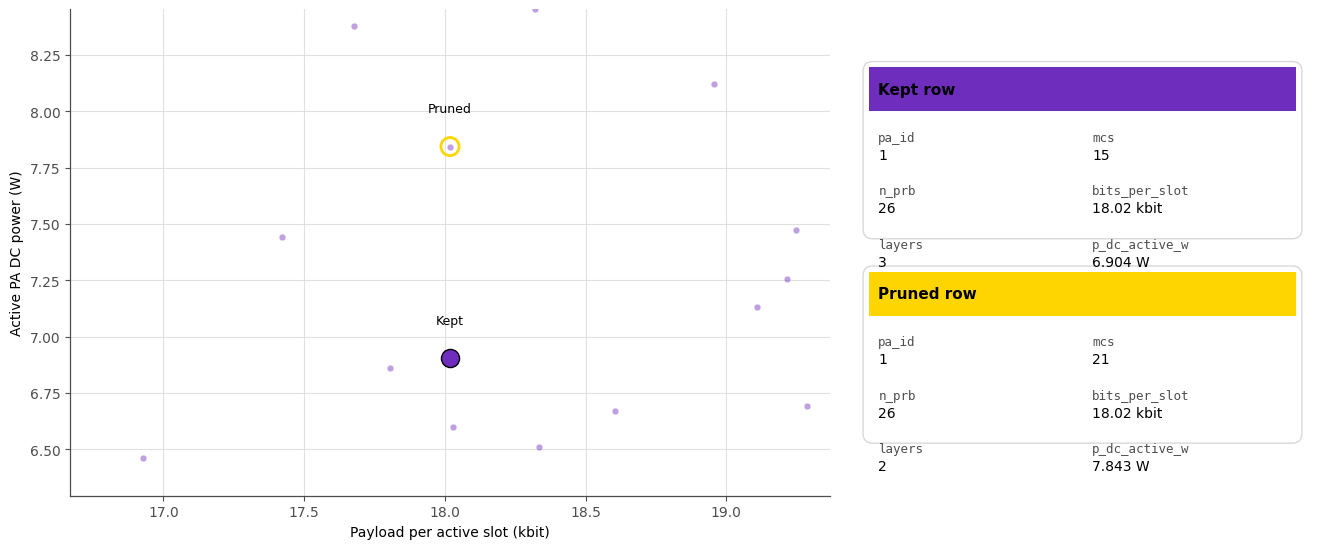

In [6]:
fig, _ = helper.plot_dominated_vs_kept_example(artifacts)
show_figure(fig)


**Worked pruning example showing one dominated row and the kept row that replaces it.**

The kept row weakly improves the pruned row on the stored comparison dimensions, and at least one axis is strictly better. The dominated row is therefore removed from the stored frontier.


## 6. Full feasible space versus stored frontier at the worked distance

This is the main before-and-after view for the worked distance bin.


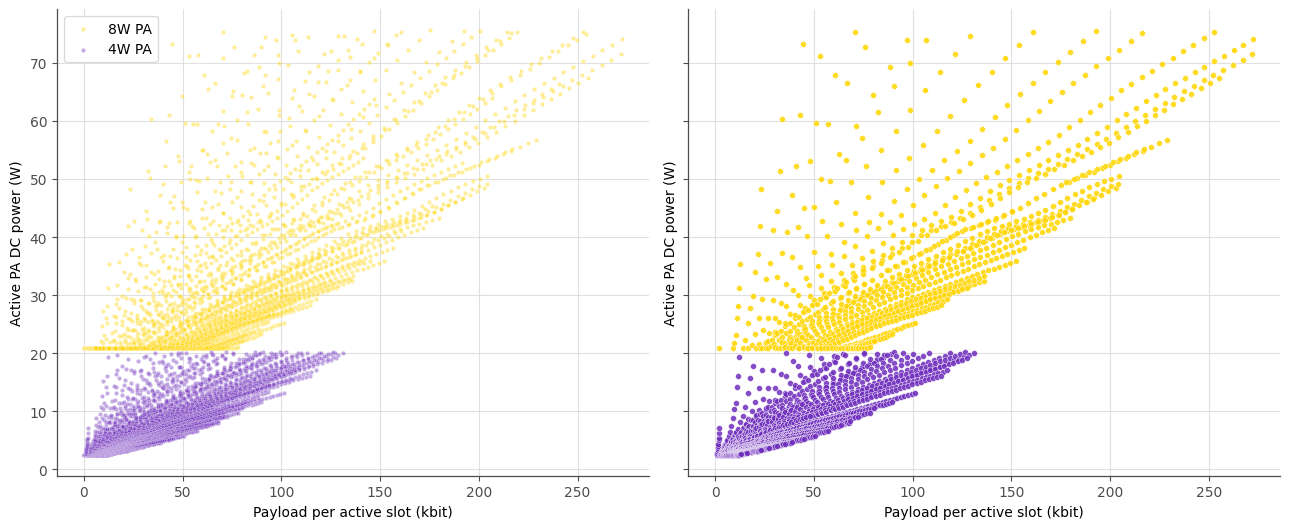

In [7]:
fig, _ = helper.plot_space_vs_frontier(artifacts)
show_figure(fig)


**From the full feasible one-slot space to the stored frontier for the worked distance bin.**

The left panel is the full feasible one-slot cloud at `300 m`. The right panel is the strict-pruned stored frontier for that same bin. The stored artifact keeps the power-efficient single-slot choices under the implemented rule.


## 7. Compare stored frontiers at two distances

The stored frontier is distance-conditioned. The next comparison keeps the same fixed NR resource envelope and shows the frontier at `50 m` and `300 m` on the same visual scale.


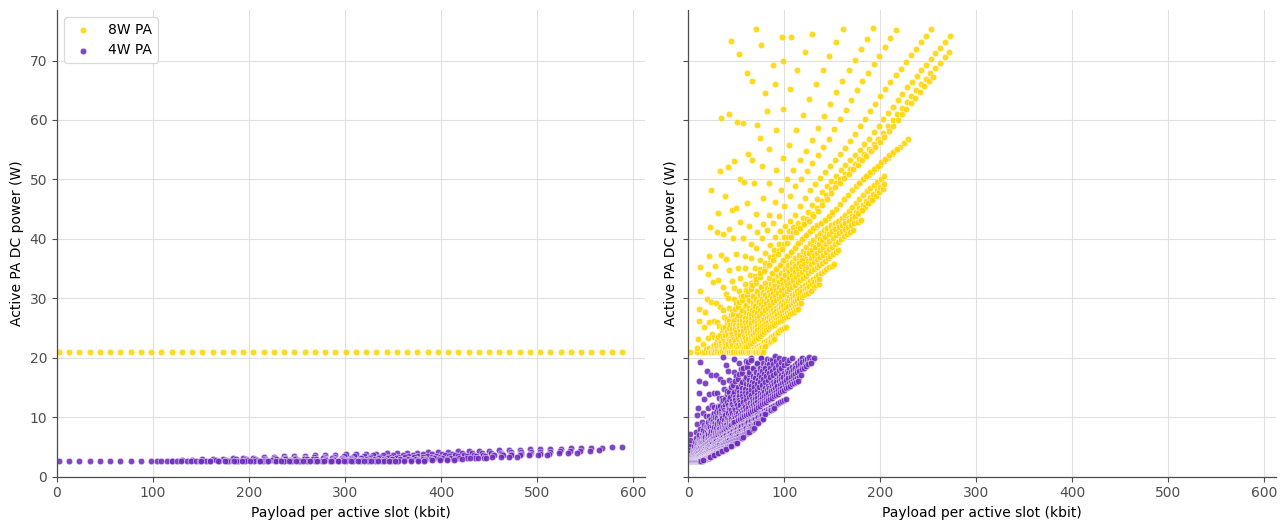

In [8]:
fig, _ = helper.plot_frontier_distance_comparison(artifacts)
show_figure(fig)


**Stored single-slot frontiers at two distances under the same fixed NR resource envelope.**

Both panels represent the same construction process. The frontier shape changes with distance because the feasible single-slot operating rows change with the distance-conditioned radio state.


## 8. Distance-bin sweep summary

The same feasible-space and pruning process is repeated across the supported static distance bins.


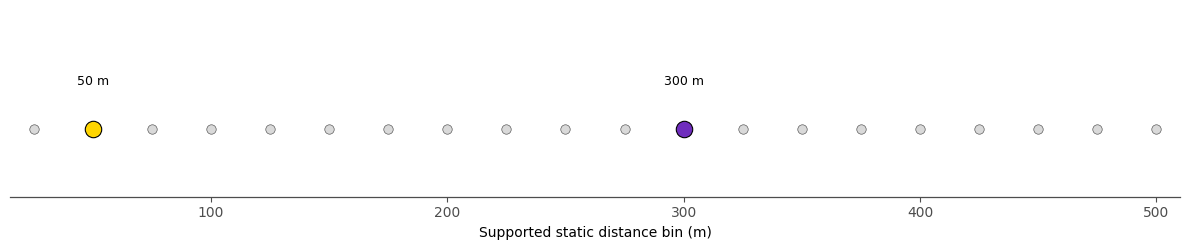

In [9]:
fig, _ = helper.plot_distance_bin_storage_strip(artifacts)
show_figure(fig)


**The same feasible-space and pruning process is repeated across the supported static distance bins.**

The worked `50 m` and `300 m` bins are highlighted here, but the same single-slot storage path is applied across the full supported distance grid.


## 9. Short handoff to the next notebook

This notebook ends at the stored distance-conditioned single-slot frontier. The next notebook snaps users to supported bins, retrieves trusted frontier rows, expands them into rate-feasible allocations, and prepares the scheduler-facing input space.


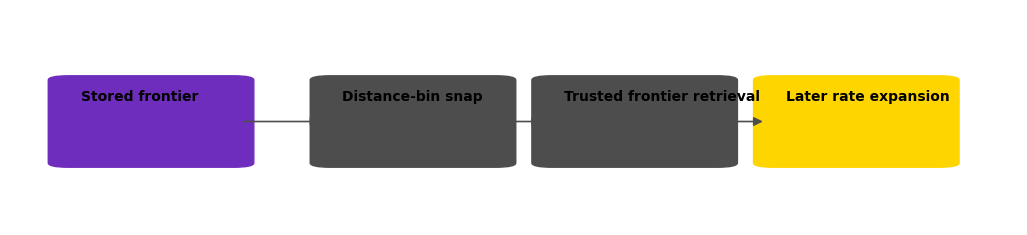

In [10]:
fig, _ = helper.plot_handoff_strip()
show_figure(fig)


**Notebook handoff from stored frontier construction to later lookup and scheduler preparation.**

The candidate-space notebook stops at the stored frontier. Later notebooks handle the distance-bin snap, trusted row retrieval, and scheduler preparation stages.
